# Brain Tumor MRI — WGAN-GP Full Pipeline
## Dataset Preprocessing · Exploratory Analysis · Training · Synthesis · Evaluation

**Section 2 — Medical Image Synthesis & Data Augmentation**  
**Dataset:** Brain Tumor MRI Dataset — 7,200 Human Brain MRI Images  
- `Training/` — glioma (1,400) · meningioma (1,400) · pituitary (1,400) · notumor (1,400)  
- `Testing/`  — glioma (400)   · meningioma (400)   · pituitary (400)   · notumor (400)  

**Architecture:** WGAN-GP — Deconvolutional Generator (nz=200) + Convolutional Critic  
**Purpose:** Generate realistic synthetic brain MRI images per tumor class for data augmentation while preserving 100% patient privacy.


In [19]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import os

print("Training path exists?", os.path.exists(TRAIN_DIR))
print("Contents of Drive MyDrive:", os.listdir('/content/drive/MyDrive') if os.path.exists('/content/drive/MyDrive') else "Drive not mounted!")

Training path exists? True
Contents of Drive MyDrive: ['bandicam 2022-06-07 15-00-36-751.mp4', 'bandicam 2022-06-07 15-07-40-314.mp4', 'bandicam 2022-06-07 15-14-58-863.mp4', 'bandicam 2022-06-07 15-25-02-827.mp4', 'bandicam 2022-06-07 15-35-06-345.mp4', 'bandicam 2022-06-07 15-45-10-618.mp4', 'bandicam 2022-06-07 15-52-30-801.mp4', 'bandicam 2022-06-07 16-00-37-408.mp4', 'bandicam 2022-06-07 16-06-55-853.mp4', 'bandicam 2022-06-07 16-15-20-666.mp4', 'bandicam 2022-06-07 16-22-20-727.mp4', 'bandicam 2022-06-07 16-27-51-493.mp4', 'bandicam 2022-06-07 16-35-35-340.mp4', 'bandicam 2022-06-07 16-42-46-187.mp4', 'bandicam 2022-06-07 16-51-45-808.mp4', 'bandicam 2022-06-07 16-55-26-758.mp4', 'bandicam 2022-11-23 15-00-15-832.mp4', 'CamScanner 11-27-2022 12.00.pdf', 'CamScanner 11-27-2022 13.53.jpg', 'CamScanner 11-27-2022 14.23.pdf', 'CamScanner 11-27-2022 14.24.pdf', 'CamScanner 11-27-2022 15.01.pdf', 'CamScanner 11-28-2022 11.06.pdf', 'InShot_20221201_125614697.jpg', 'InShot_20221201_14252

## 1. Imports & Environment Setup

In [21]:
import os, glob, random, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from collections import Counter

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import entropy as kl_entropy

warnings.filterwarnings("ignore")
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow : {tf.__version__}")
print(f"GPUs found : {len(tf.config.list_physical_devices('GPU'))}")
print("Environment ready.")

TensorFlow : 2.20.0
GPUs found : 1
Environment ready.


## 2. Configuration & Hyperparameters

In [22]:
# ── Dataset ────────────────────────────────────────────────────────────────

# ── Dataset ────────────────────────────────────────────────────────────────
DATASET_ROOT = "."
TRAIN_DIR    = "/content/drive/MyDrive/Training"
TEST_DIR     = "/content/drive/MyDrive/Testing"
MRI_CLASSES  = ["glioma", "meningioma", "notumor", "pituitary"]

# ── Image ──────────────────────────────────────────────────────────────────
IMG_SIZE     = 64
IMG_CHANNELS = 1

# ── WGAN-GP Hyperparameters (from user provided Lasagne/Theano code) ───────
NZ           = 200           # Latent vector dimension
LAMBDA_GP    = 10            # Gradient penalty weight (lambda)
N_CRITIC     = 5             # Critic updates per generator update
BATCH_SIZE   = 32
EPOCHS       = 50            # Increase for better quality
LR_GEN       = 2e-4          # Adam lr generator (updated for WGAN-GP convergence)
LR_CRIT      = 2e-4          # Adam lr critic
BETA_1       = 0.5
BETA_2       = 0.9

# ── Output dirs ────────────────────────────────────────────────────────────
WEIGHTS_DIR  = "saved_weights"
MONTAGE_DIR  = "montages"
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(MONTAGE_DIR,  exist_ok=True)

# ── Which class to train on ─────────────────────────────────────────────────
TARGET_CLASS = "glioma"     # Change to: meningioma | notumor | pituitary

print("Configuration:")
for k, v in dict(TARGET_CLASS=TARGET_CLASS, IMG_SIZE=IMG_SIZE, NZ=NZ,
                 LAMBDA_GP=LAMBDA_GP, N_CRITIC=N_CRITIC,
                 EPOCHS=EPOCHS, BATCH_SIZE=BATCH_SIZE).items():
    print(f"  {k:<14}: {v}")

Configuration:
  TARGET_CLASS  : glioma
  IMG_SIZE      : 64
  NZ            : 200
  LAMBDA_GP     : 10
  N_CRITIC      : 5
  EPOCHS        : 50
  BATCH_SIZE    : 32


## 3. Dataset Scanning & Exploratory Analysis
### 3.1 File Registry

In [23]:
registry = {"Training": {}, "Testing": {}}
for split, base in [("Training", TRAIN_DIR), ("Testing", TEST_DIR)]:
    for cls in MRI_CLASSES:
        folder = os.path.join(base, cls)
        files  = (glob.glob(os.path.join(folder, "*.jpg")) +
                  glob.glob(os.path.join(folder, "*.jpeg")) +
                  glob.glob(os.path.join(folder, "*.png")))
        registry[split][cls] = files

rows = []
for cls in MRI_CLASSES:
    tr = len(registry["Training"][cls])
    te = len(registry["Testing"][cls])
    rows.append({"Class": cls, "Training": tr, "Testing": te, "Total": tr + te})

df_summary = pd.DataFrame(rows)
df_summary.loc[len(df_summary)] = [
    "TOTAL",
    df_summary["Training"].sum(),
    df_summary["Testing"].sum(),
    df_summary["Total"].sum()
]

print(df_summary.to_string(index=False))

     Class  Training  Testing  Total
    glioma      1400      400   1800
meningioma      1400      400   1800
   notumor      1400      400   1800
 pituitary      1400      400   1800
     TOTAL      5600     1600   7200


### 3.2 Class Distribution Chart

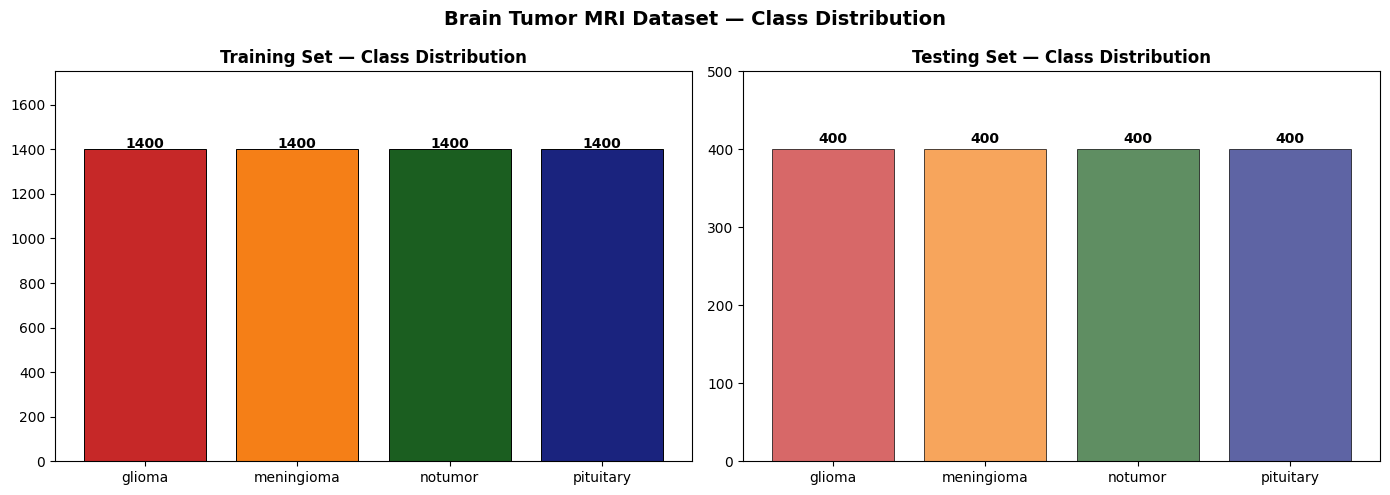

In [24]:
colors = ["#C62828","#F57F17","#1B5E20","#1A237E"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, split, alpha in zip(axes, ["Training","Testing"], [1.0, 0.7]):
    counts = [len(registry[split][c]) for c in MRI_CLASSES]
    bars   = ax.bar(MRI_CLASSES, counts, color=colors, edgecolor="black", lw=0.7, alpha=alpha)
    for b, v in zip(bars, counts):
        ax.text(b.get_x()+b.get_width()/2, v+8, str(v), ha="center", fontweight="bold")
    ax.set_title(f"{split} Set — Class Distribution", fontweight="bold")
    ax.set_ylim(0, max(counts)*1.25)
plt.suptitle("Brain Tumor MRI Dataset — Class Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("montages/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.3 Sample Real MRI Images per Class

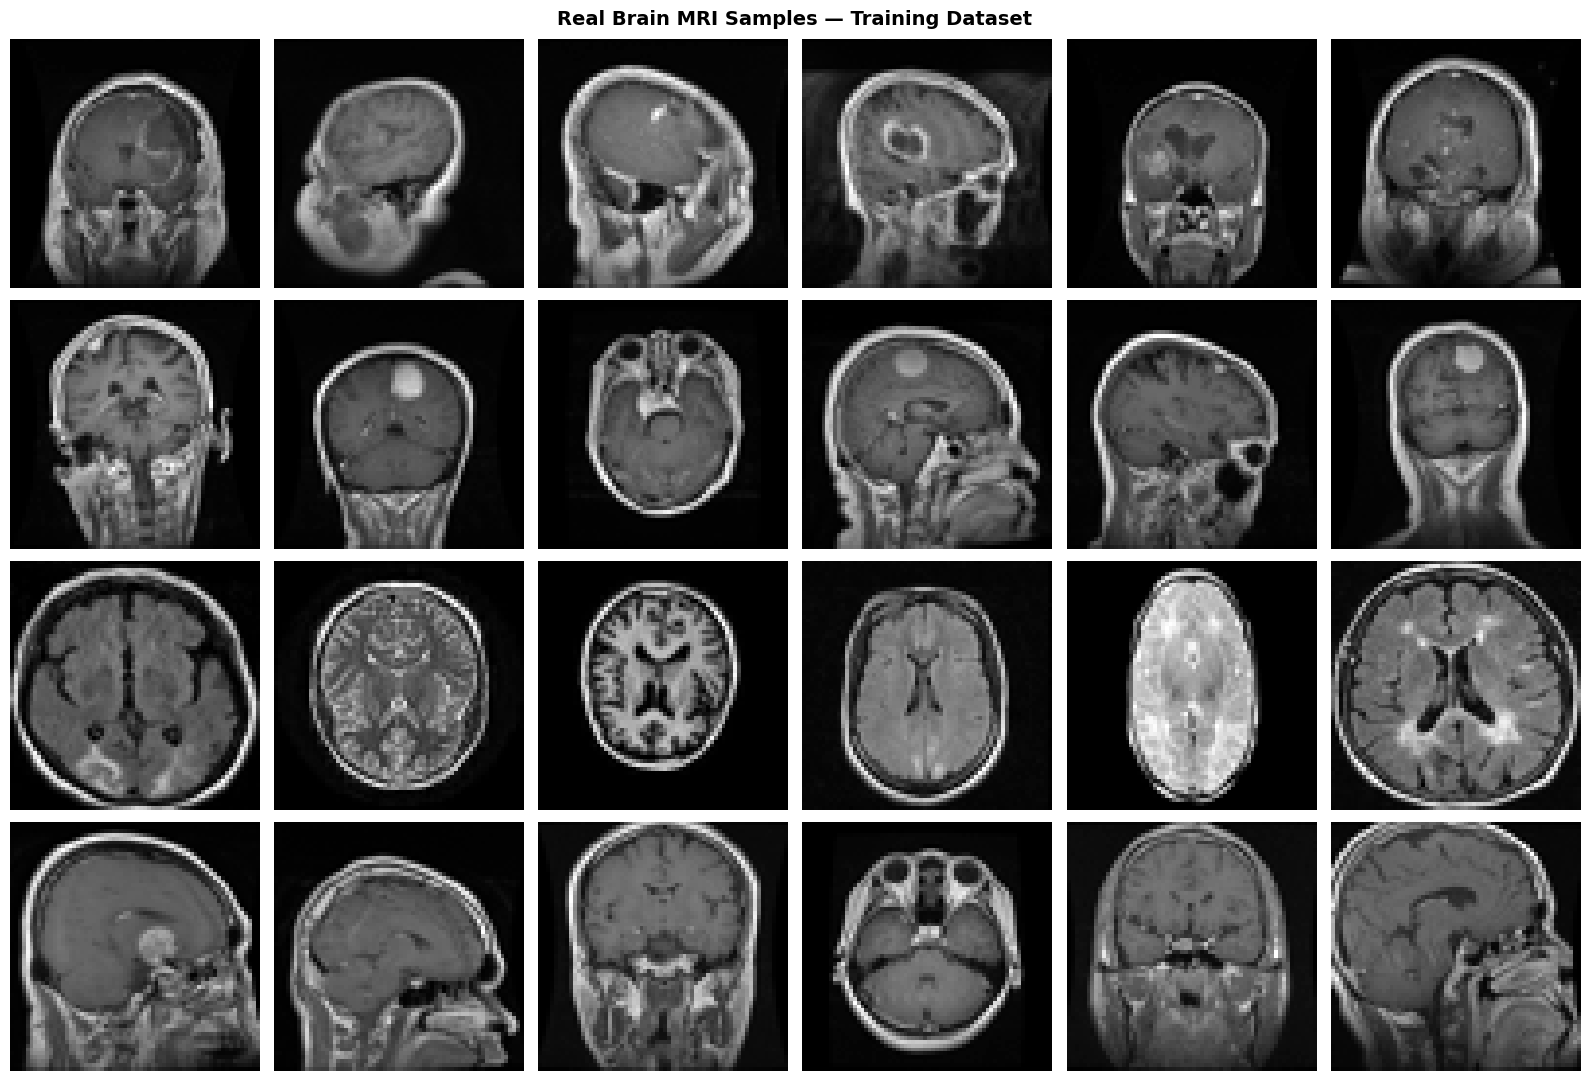

In [25]:
class_colors = {"glioma":"#C62828","meningioma":"#F57F17","notumor":"#1B5E20","pituitary":"#1A237E"}
fig, axes = plt.subplots(len(MRI_CLASSES), 6, figsize=(16, 11))
fig.suptitle("Real Brain MRI Samples — Training Dataset", fontsize=14, fontweight="bold")
for row, cls in enumerate(MRI_CLASSES):
    files = random.sample(registry["Training"][cls], 6)
    for col, fp in enumerate(files):
        img = Image.open(fp).convert("L").resize((IMG_SIZE, IMG_SIZE))
        axes[row, col].imshow(np.array(img), cmap="gray")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(cls.upper(), fontsize=11,
                color=class_colors[cls], fontweight="bold",
                rotation=0, labelpad=60, va="center")
plt.tight_layout()
plt.savefig("montages/real_samples_grid.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.4 Pixel Intensity Distribution per Class

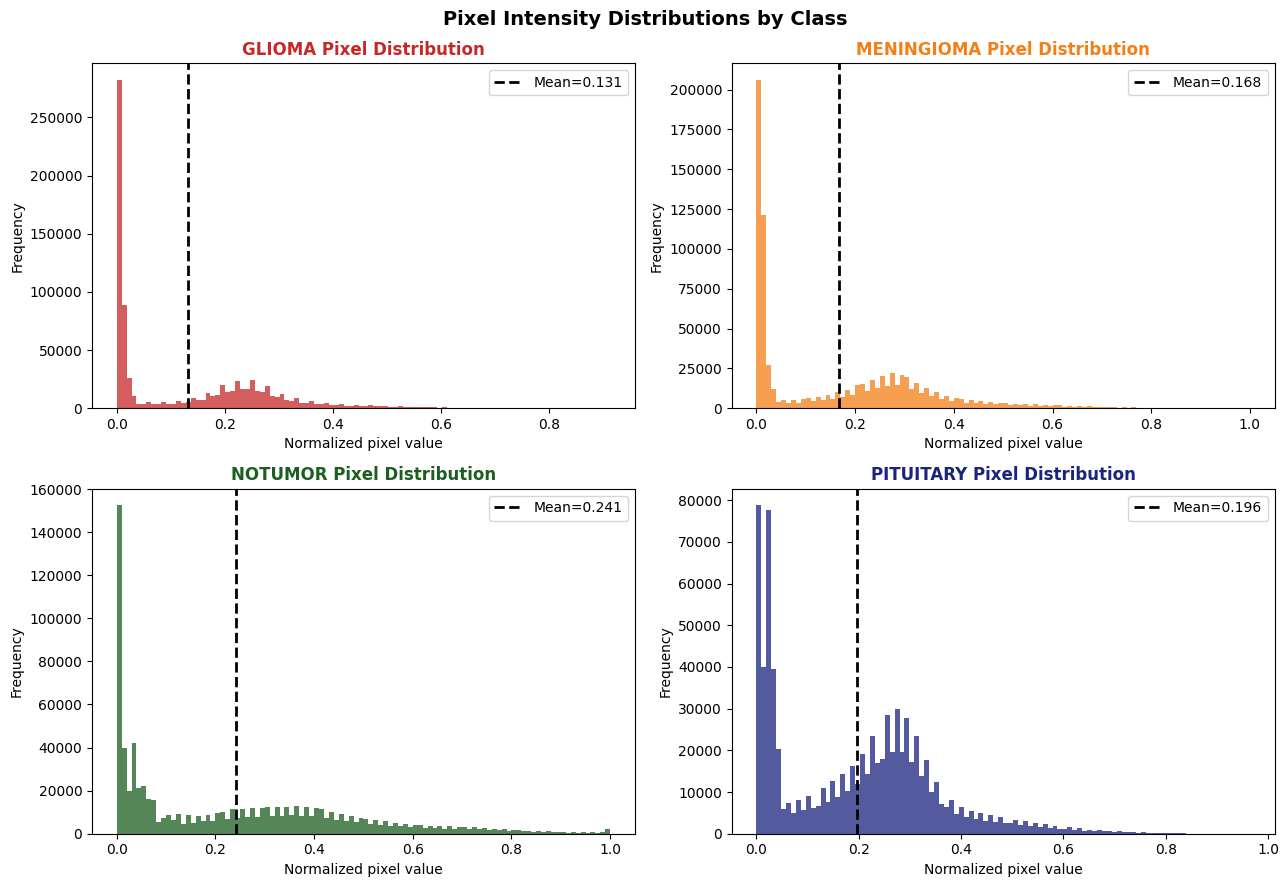

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
for idx, (cls, color) in enumerate(zip(MRI_CLASSES, colors)):
    pxl = []
    for fp in registry["Training"][cls][:200]:
        try:
            img = Image.open(fp).convert("L").resize((IMG_SIZE, IMG_SIZE))
            pxl.extend(np.array(img).flatten().tolist())
        except: pass
    pxl = np.array(pxl, dtype=np.float32) / 255.0
    axes[idx].hist(pxl, bins=100, color=color, alpha=0.75, edgecolor="none")
    axes[idx].axvline(pxl.mean(), color="black", ls="--", lw=2,
                       label=f"Mean={pxl.mean():.3f}")
    axes[idx].set_title(f"{cls.upper()} Pixel Distribution", fontweight="bold", color=color)
    axes[idx].set_xlabel("Normalized pixel value")
    axes[idx].set_ylabel("Frequency")
    axes[idx].legend()
plt.suptitle("Pixel Intensity Distributions by Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("montages/pixel_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.5 Mean MRI Image per Class

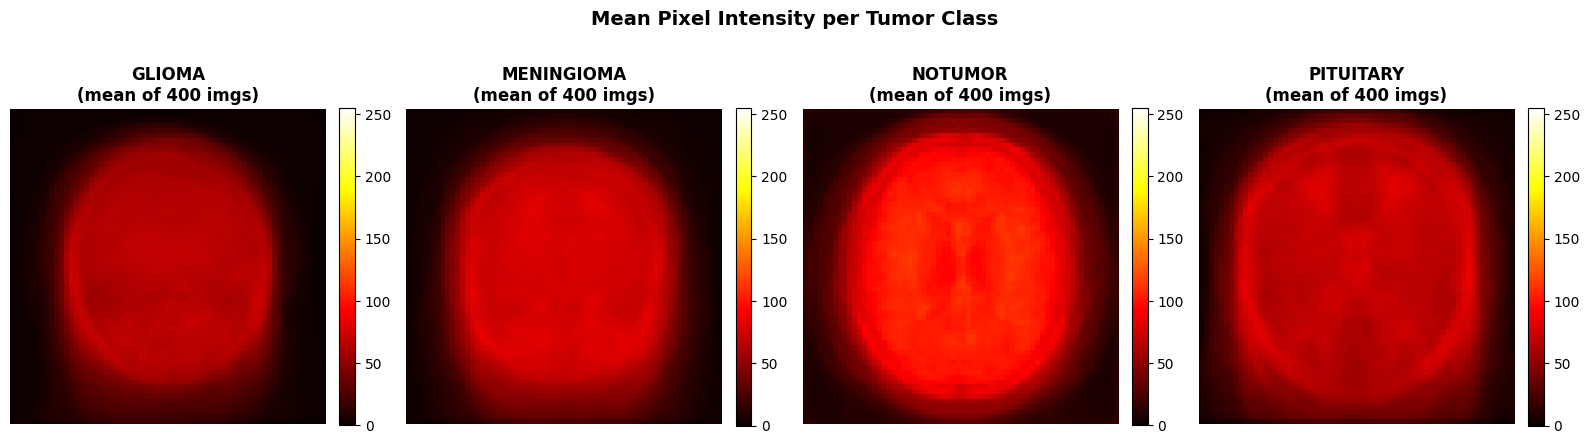

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for idx, cls in enumerate(MRI_CLASSES):
    frames = []
    for fp in registry["Training"][cls][:400]:
        try:
            img = Image.open(fp).convert("L").resize((IMG_SIZE, IMG_SIZE))
            frames.append(np.array(img, dtype=np.float32))
        except: pass
    mean_img = np.mean(frames, axis=0)
    im = axes[idx].imshow(mean_img, cmap="hot", vmin=0, vmax=255)
    axes[idx].set_title(f"{cls.upper()}\n(mean of {len(frames)} imgs)",
                         fontweight="bold")
    axes[idx].axis("off")
    plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
plt.suptitle("Mean Pixel Intensity per Tumor Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("montages/mean_images.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Dataset Preprocessing
### 4.1 Load & Normalize Images

In [28]:
def load_class_images(cls, split="Training", max_images=1400, verbose=True):
    """
    Load MRI images for one class.
    Returns np.ndarray (N, IMG_SIZE, IMG_SIZE, 1) normalized to [-1, 1].
    """
    files = registry[split][cls][:]
    random.shuffle(files)
    files = files[:max_images]
    imgs  = []
    for fp in files:
        try:
            img = Image.open(fp).convert("L").resize(
                (IMG_SIZE, IMG_SIZE), Image.BILINEAR)
            # Normalize to [-1, 1] range for Tanh generator output
            imgs.append((np.array(img, dtype=np.float32) / 127.5) - 1.0)
        except Exception as e:
            if verbose: print(f"  Warning: {fp}: {e}")
    data = np.stack(imgs, axis=0)[:, :, :, np.newaxis]   # (N,64,64,1)
    if verbose:
        print(f"Loaded {len(data)} {split}/{cls} images")
        print(f"  Shape: {data.shape}  |  Min: {data.min():.3f}  Max: {data.max():.3f}")
        print(f"  Mean : {data.mean():.4f}  |  Std: {data.std():.4f}")
    return data

real_images = load_class_images(TARGET_CLASS, split="Training")

Loaded 1400 Training/glioma images
  Shape: (1400, 64, 64, 1)  |  Min: -1.000  Max: 0.812
  Mean : -0.7404  |  Std: 0.2885


### 4.2 Build tf.data.Dataset Pipeline

In [29]:
def build_tf_dataset(images, batch_size=BATCH_SIZE, shuffle_buffer=1000):
    ds = tf.data.Dataset.from_tensor_slices(images.astype(np.float32))
    ds = ds.shuffle(shuffle_buffer)
    ds = ds.batch(batch_size, drop_remainder=True)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = build_tf_dataset(real_images)
for batch in train_ds.take(1):
    print(f"Batch shape : {batch.shape}")
    print(f"Min / Max   : {batch.numpy().min():.4f} / {batch.numpy().max():.4f}")

Batch shape : (32, 64, 64, 1)
Min / Max   : -1.0000 / 0.5451


## 5. WGAN-GP Model Architecture
### 5.1 Generator (nz=200 — Deconv Architecture with Tanh activation)
```
z ∈ R^200
  Dense(1024×4×4) → Reshape(4,4,1024)
  Conv2DTranspose(512, 4×4, s=2) + BN + ReLU  →  8×8×512
  Conv2DTranspose(256, 4×4, s=2) + BN + ReLU  → 16×16×256
  Conv2DTranspose(128, 4×4, s=2) + BN + ReLU  → 32×32×128
  Conv2DTranspose(  1, 4×4, s=2) + Tanh        → 64×64×1  [[-1, 1] output]
```


In [30]:
def build_generator(nz=NZ):
    inp = layers.Input(shape=(nz,))
    x   = layers.Dense(1024*4*4, use_bias=False)(inp)
    x   = layers.Reshape((4, 4, 1024))(x)
    # Block 1: 4→8
    x   = layers.Conv2DTranspose(512, 4, strides=2, padding="same", use_bias=False)(x)
    x   = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    # Block 2: 8→16
    x   = layers.Conv2DTranspose(256, 4, strides=2, padding="same", use_bias=False)(x)
    x   = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    # Block 3: 16→32
    x   = layers.Conv2DTranspose(128, 4, strides=2, padding="same", use_bias=False)(x)
    x   = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    # Block 4: 32→64 (Tanh activation for output in [-1, 1])
    x   = layers.Conv2DTranspose(1, 4, strides=2, padding="same", activation="tanh")(x)
    return models.Model(inp, x, name="WGANGP_Generator")

generator = build_generator()
generator.summary()

Model: "WGANGP_Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16384)          │     3,276,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 512)      │     8,388,608 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 256)    │     2,097,152 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 1)      │         2,049 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,292,481 (54.52 MB)

 Trainable params: 14,290,689 (54.51 MB)

 Non-trainable params: 1,792 (7.00 KB)

### 5.2 Critic / Discriminator (No Batch Normalization for 1-Lipschitz Condition)
```
x ∈ R^{64×64×1}
  Conv2D(128,  5×5, s=2) + LReLU(0.2) → 32×32×128
  Conv2D(256,  5×5, s=2) + LReLU(0.2) → 16×16×256
  Conv2D(512,  5×5, s=2) + LReLU(0.2) →  8×8×512
  Conv2D(1024, 5×5, s=2) + LReLU(0.2) →  4×4×1024
  Flatten → Dense(1)   [No BN — preserves 1-Lipschitz & Gradient Penalty validity]
```


In [31]:
def build_critic(img_shape=(IMG_SIZE, IMG_SIZE, IMG_CHANNELS)):
    inp = layers.Input(shape=img_shape)
    # NO BatchNormalization in Critic! BN introduces inter-sample dependencies
    # violating 1-Lipschitz continuity and invalidating the Gradient Penalty calculation.
    x   = layers.Conv2D(128,  5, strides=2, padding="same", use_bias=True)(inp)
    x   = layers.LeakyReLU(0.2)(x)
    x   = layers.Conv2D(256,  5, strides=2, padding="same", use_bias=True)(x)
    x   = layers.LeakyReLU(0.2)(x)
    x   = layers.Conv2D(512,  5, strides=2, padding="same", use_bias=True)(x)
    x   = layers.LeakyReLU(0.2)(x)
    x   = layers.Conv2D(1024, 5, strides=2, padding="same", use_bias=True)(x)
    x   = layers.LeakyReLU(0.2)(x)
    x   = layers.Flatten()(x)
    x   = layers.Dense(1)(x)   # Wasserstein score output (no activation)
    return models.Model(inp, x, name="WGANGP_Critic")

critic = build_critic()
critic.summary()

Model: "WGANGP_Critic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 128)    │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 256)    │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 512)      │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 1024)     │    13,108,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 4, 4, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        16,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,224,705 (65.71 MB)

 Trainable params: 17,224,705 (65.71 MB)

 Non-trainable params: 0 (0.00 B)

### 5.3 Optimizers

In [32]:
# Adam (lr=2e-4, beta_1=0.5, beta_2=0.9) — standard WGAN-GP learning rate
g_optimizer = tf.keras.optimizers.Adam(learning_rate=LR_GEN,  beta_1=BETA_1, beta_2=BETA_2)
d_optimizer = tf.keras.optimizers.Adam(learning_rate=LR_CRIT, beta_1=BETA_1, beta_2=BETA_2)
print(f"G optimizer: Adam(lr={LR_GEN}, b1={BETA_1}, b2={BETA_2})")
print(f"D optimizer: Adam(lr={LR_CRIT}, b1={BETA_1}, b2={BETA_2})")

G optimizer: Adam(lr=0.0002, b1=0.5, b2=0.9)
D optimizer: Adam(lr=0.0002, b1=0.5, b2=0.9)


## 6. WGAN-GP Training
### 6.1 Gradient Penalty
$$\text{GP} = \lambda \cdot \mathbb{E}\left[\left(\|\nabla_{\hat{x}} D(\hat{x})\|_2 - 1\right)^2\right], \quad \hat{x} = \alpha x_\text{real} + (1-\alpha) x_\text{fake}$$


In [33]:
@tf.function
def compute_gradient_penalty(critic, real_imgs, fake_imgs, lam=LAMBDA_GP):
    batch = tf.shape(real_imgs)[0]
    alpha = tf.random.uniform([batch, 1, 1, 1], 0.0, 1.0)
    interp = alpha * real_imgs + (1.0 - alpha) * fake_imgs
    with tf.GradientTape() as tape:
        tape.watch(interp)
        pred = critic(interp, training=True)
    grads      = tape.gradient(pred, interp)
    grad_norm  = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1,2,3]) + 1e-12)
    return lam * tf.reduce_mean(tf.square(grad_norm - 1.0))
print("Gradient penalty defined.")

Gradient penalty defined.


### 6.2 Train Step Functions

In [34]:
@tf.function
def train_critic_step(real_batch):
    """Critic loss = E[D(fake)] - E[D(real)] + GP"""
    n = tf.shape(real_batch)[0]
    z = tf.random.normal([n, NZ])
    with tf.GradientTape() as tape:
        fake        = generator(z, training=True)
        real_score  = critic(real_batch, training=True)
        fake_score  = critic(fake,       training=True)
        gp          = compute_gradient_penalty(critic, real_batch, fake)
        d_loss      = tf.reduce_mean(fake_score) - tf.reduce_mean(real_score) + gp
    grads = tape.gradient(d_loss, critic.trainable_variables)
    d_optimizer.apply_gradients(zip(grads, critic.trainable_variables))
    return d_loss, gp

@tf.function
def train_generator_step(batch_size):
    """Generator loss = -E[D(G(z))]"""
    z = tf.random.normal([batch_size, NZ])
    with tf.GradientTape() as tape:
        fake       = generator(z, training=True)
        fake_score = critic(fake, training=True)
        g_loss     = -tf.reduce_mean(fake_score)
    grads = tape.gradient(g_loss, generator.trainable_variables)
    g_optimizer.apply_gradients(zip(grads, generator.trainable_variables))
    return g_loss

print("Train step functions compiled.")

Train step functions compiled.


### 6.3 Montage Helper (matches `create_montage` from user code)

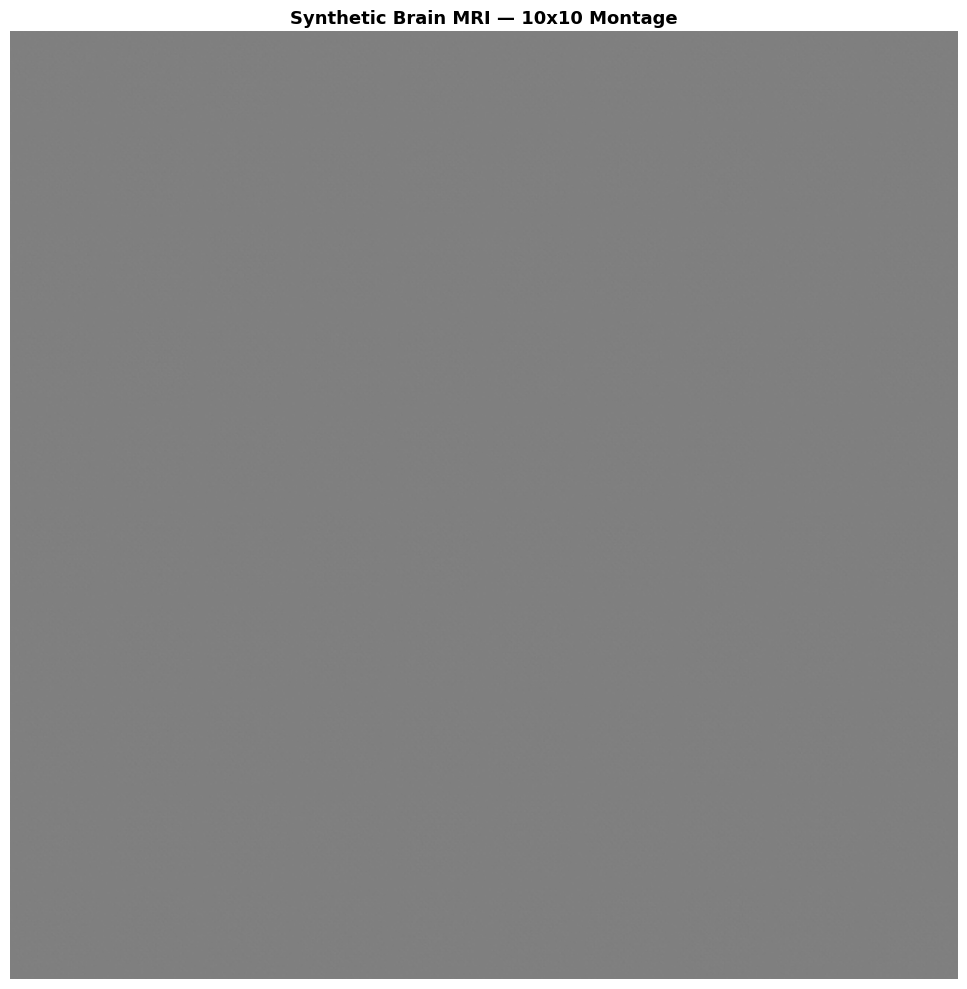

Untrained (random) montage shown.


In [35]:
def create_montage(gen, nz=NZ, grid=10, save_path=None):
    """10x10 grid of 100 synthetic MRI images."""
    n      = grid * grid
    z      = tf.random.normal([n, nz])
    raw    = gen(z, training=False).numpy()[:, :, :, 0]
    # Rescale Tanh output [-1, 1] -> [0, 1] for grid visualization & saving
    imgs   = np.clip((raw + 1.0) / 2.0, 0.0, 1.0)
    h, w   = imgs.shape[1], imgs.shape[2]
    canvas = np.zeros((grid*h, grid*w), dtype=np.float32)
    for idx in range(n):
        r, c = divmod(idx, grid)
        canvas[r*h:(r+1)*h, c*w:(c+1)*w] = imgs[idx]
    if save_path:
        plt.imsave(save_path, canvas, cmap="gray", vmin=0, vmax=1)
    return canvas

def show_montage(canvas, title="Synthetic Brain MRI — 10x10 Montage", epoch=None):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(canvas, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"{title}" + (f" (Epoch {epoch})" if epoch else ""), fontsize=13, fontweight="bold")
    ax.axis("off")
    plt.tight_layout(); plt.show()

canvas0 = create_montage(generator, save_path="montages/montage_epoch_000.png")
show_montage(canvas0, epoch=0)
print("Untrained (random) montage shown.")

### 6.4 Full Training Loop

Training: class=glioma  epochs=50  steps/epoch=43  n_critic=5
------------------------------------------------------------


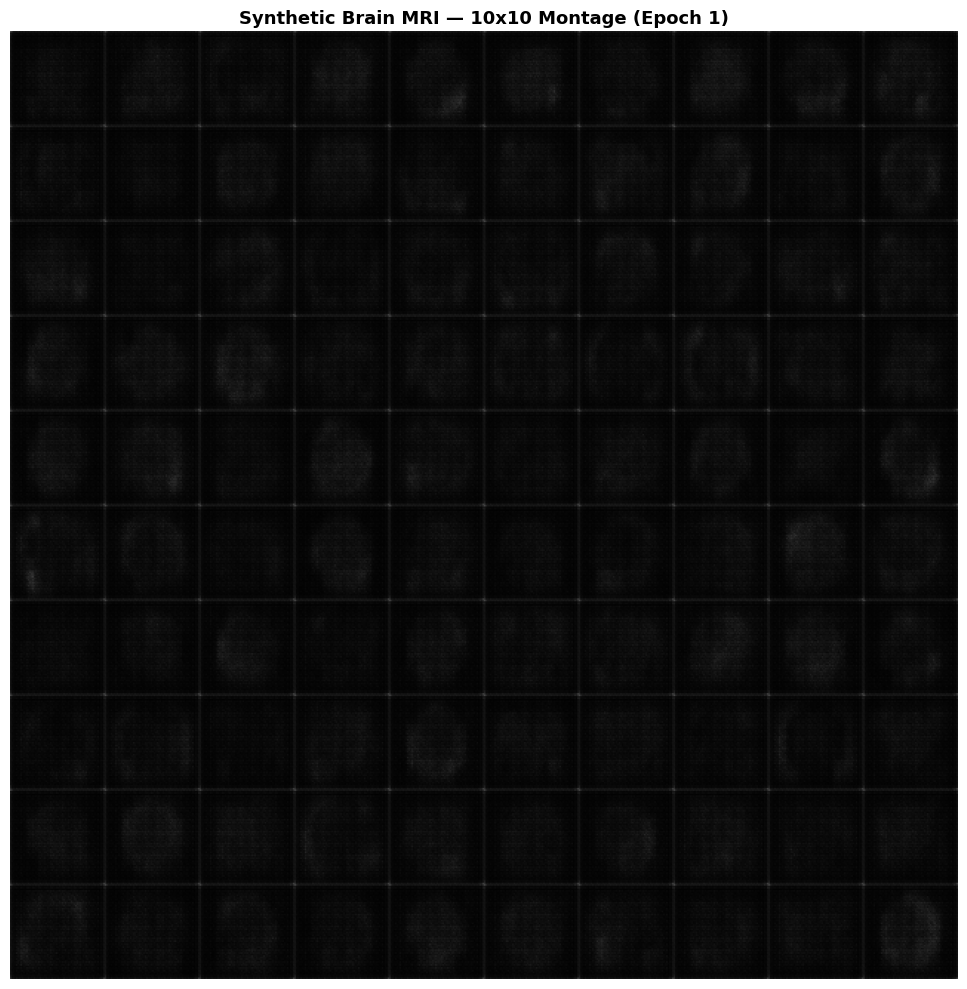

Epoch   1/50 | D=-26.8180 | G=-32.6234 | GP=11.0265 | 71.6s
Epoch   2/50 | D=-7.9109 | G=-16.1812 | GP=1.1470 | 74.7s
Epoch   3/50 | D=-6.2785 | G=-11.3900 | GP=0.7953 | 77.1s
Epoch   4/50 | D=-5.3856 | G=-7.9285 | GP=0.7140 | 77.7s
Epoch   5/50 | D=-4.9391 | G=-6.0750 | GP=0.5911 | 77.5s
Epoch   6/50 | D=-4.8148 | G=-2.8791 | GP=0.6302 | 77.9s
Epoch   7/50 | D=-4.6419 | G=-1.4895 | GP=0.6101 | 78.0s
Epoch   8/50 | D=-4.4835 | G=-0.9822 | GP=0.6410 | 77.9s
Epoch   9/50 | D=-4.3193 | G= 0.5170 | GP=0.5663 | 77.8s


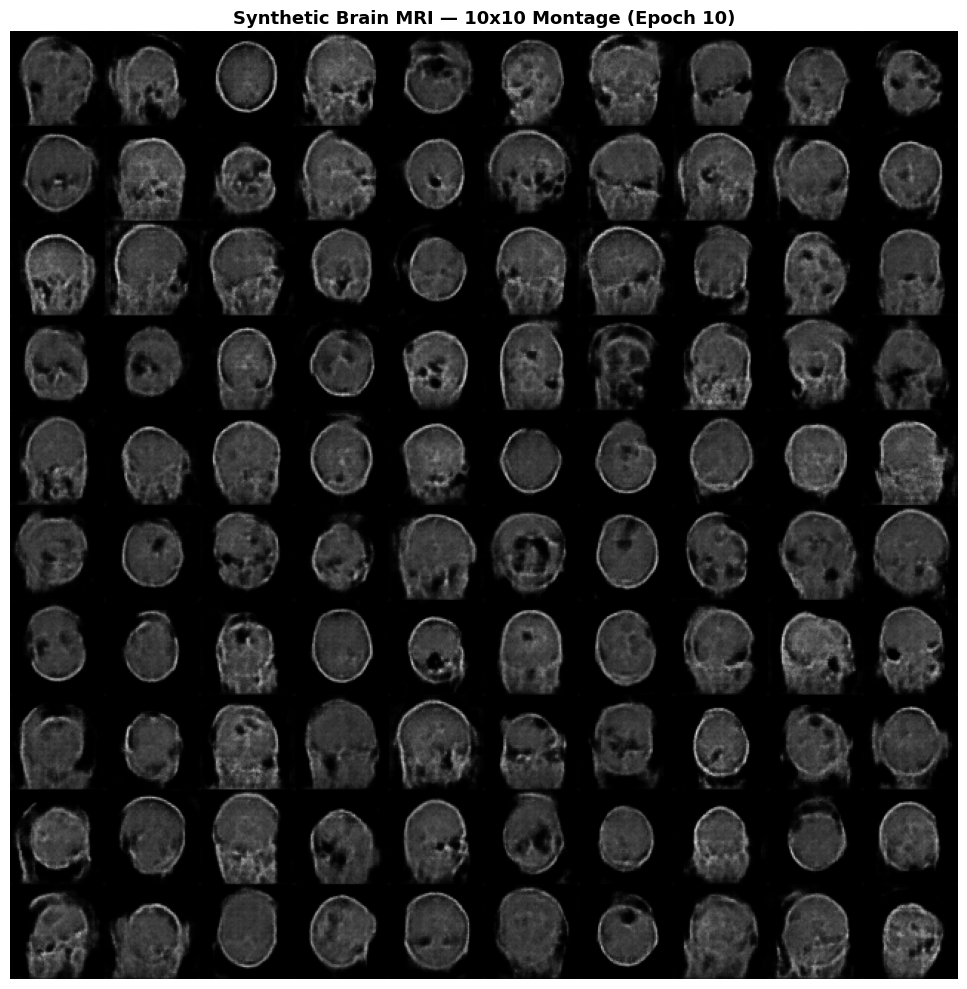

Epoch  10/50 | D=-4.3603 | G= 1.2072 | GP=0.5531 | 78.4s
Epoch  11/50 | D=-4.1857 | G= 0.4151 | GP=0.5516 | 77.4s
Epoch  12/50 | D=-4.2540 | G= 1.2079 | GP=0.5623 | 77.5s
Epoch  13/50 | D=-4.1724 | G= 1.8605 | GP=0.5588 | 77.5s
Epoch  14/50 | D=-4.0905 | G= 2.1989 | GP=0.5297 | 77.5s
Epoch  15/50 | D=-3.9971 | G= 2.3259 | GP=0.5204 | 77.5s
Epoch  16/50 | D=-4.0639 | G= 3.7932 | GP=0.5904 | 77.5s
Epoch  17/50 | D=-4.0148 | G= 3.0772 | GP=0.5104 | 77.4s
Epoch  18/50 | D=-4.0321 | G= 3.1484 | GP=0.5171 | 77.4s
Epoch  19/50 | D=-4.0917 | G= 3.7779 | GP=0.4667 | 77.4s


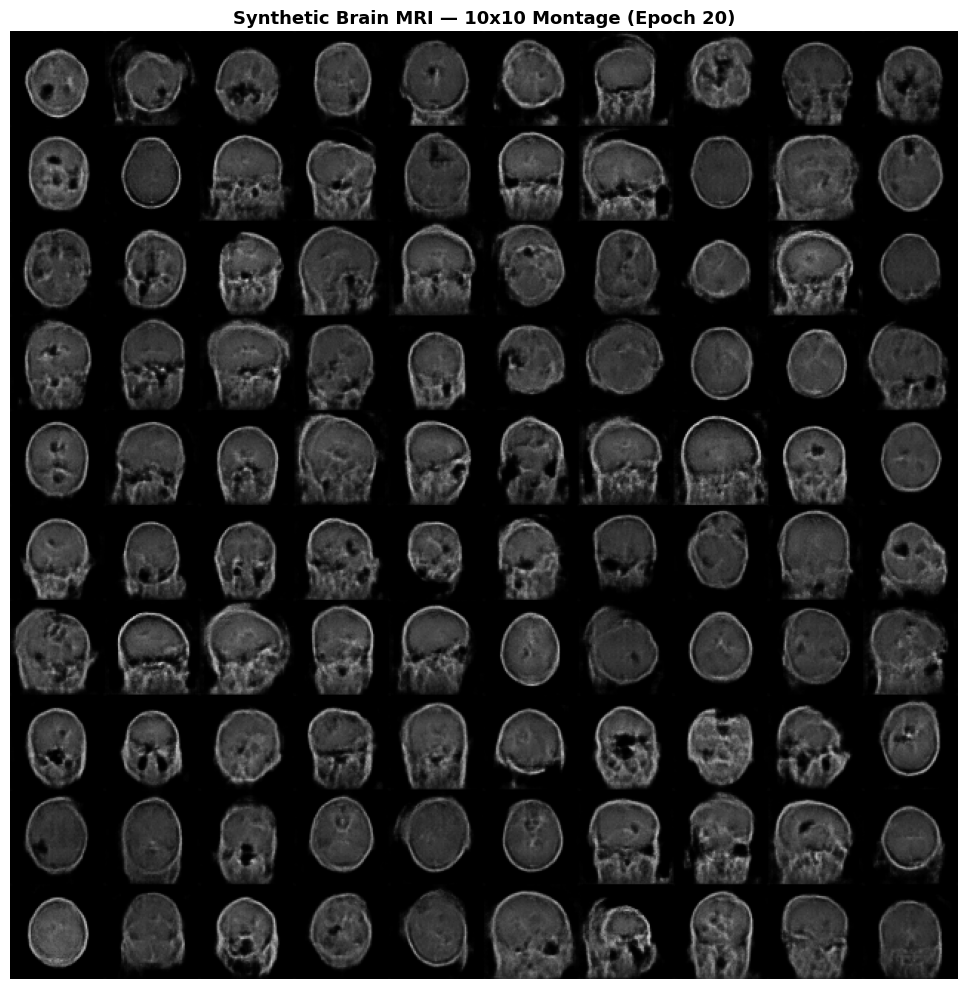

Epoch  20/50 | D=-4.0216 | G= 3.4486 | GP=0.4891 | 78.5s
Epoch  21/50 | D=-4.0485 | G= 3.8004 | GP=0.5236 | 77.7s
Epoch  22/50 | D=-4.0187 | G= 3.3148 | GP=0.4793 | 78.2s
Epoch  23/50 | D=-4.0652 | G= 3.7126 | GP=0.4825 | 77.9s
Epoch  24/50 | D=-4.1032 | G= 3.7474 | GP=0.4513 | 77.8s
Epoch  25/50 | D=-3.9427 | G= 4.2277 | GP=0.4974 | 77.8s
Epoch  26/50 | D=-4.1681 | G= 3.3164 | GP=0.5394 | 77.8s
Epoch  27/50 | D=-4.1460 | G= 3.2555 | GP=0.4750 | 77.8s
Epoch  28/50 | D=-4.0438 | G= 4.2278 | GP=0.4896 | 77.7s
Epoch  29/50 | D=-4.1101 | G= 4.6761 | GP=0.4563 | 77.7s


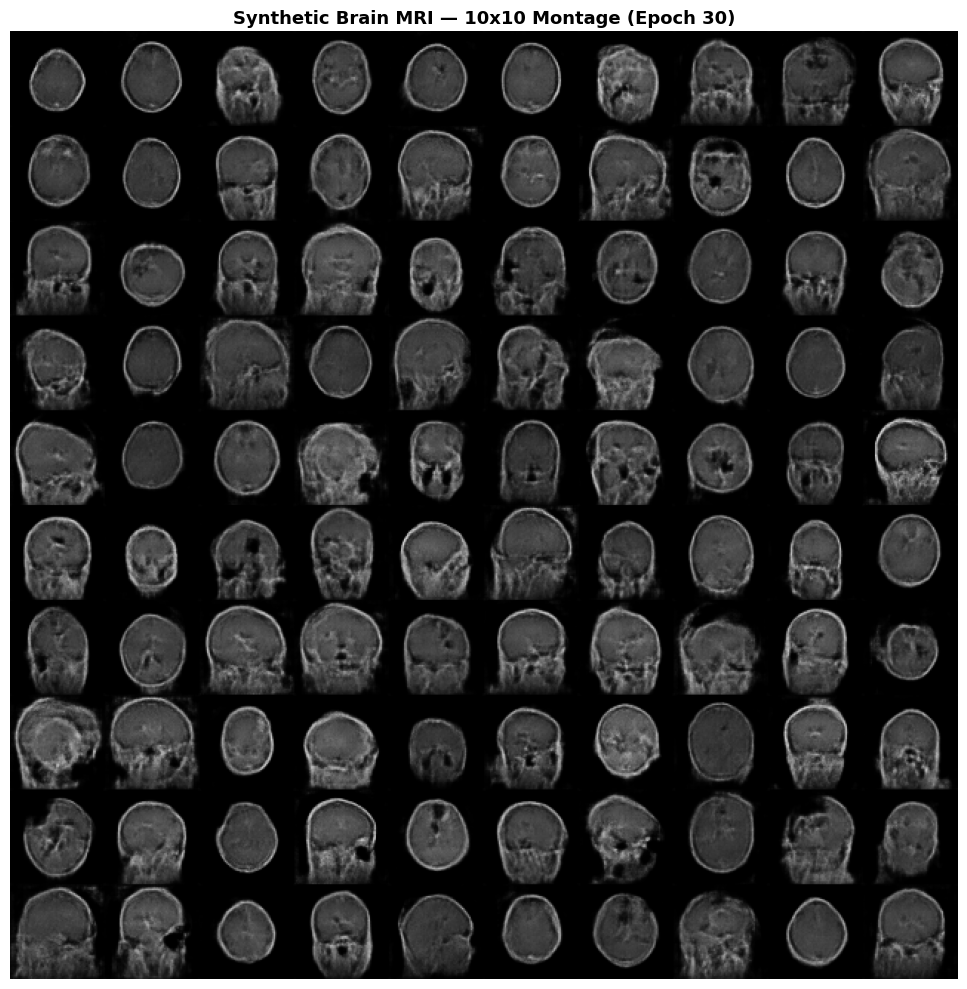

Epoch  30/50 | D=-3.9947 | G= 3.7465 | GP=0.4833 | 78.4s
Epoch  31/50 | D=-3.8947 | G= 3.9411 | GP=0.4566 | 77.6s
Epoch  32/50 | D=-4.0739 | G= 3.7232 | GP=0.4408 | 77.6s
Epoch  33/50 | D=-4.2157 | G= 3.6847 | GP=0.4983 | 77.6s
Epoch  34/50 | D=-4.1557 | G= 4.7196 | GP=0.4671 | 77.8s
Epoch  35/50 | D=-4.1258 | G= 5.1214 | GP=0.4957 | 77.8s
Epoch  36/50 | D=-4.2724 | G= 4.4285 | GP=0.4733 | 77.8s
Epoch  37/50 | D=-4.1292 | G= 4.8225 | GP=0.5122 | 77.8s
Epoch  38/50 | D=-4.1715 | G= 3.8909 | GP=0.4349 | 77.9s
Epoch  39/50 | D=-4.2205 | G= 4.8215 | GP=0.4980 | 77.8s


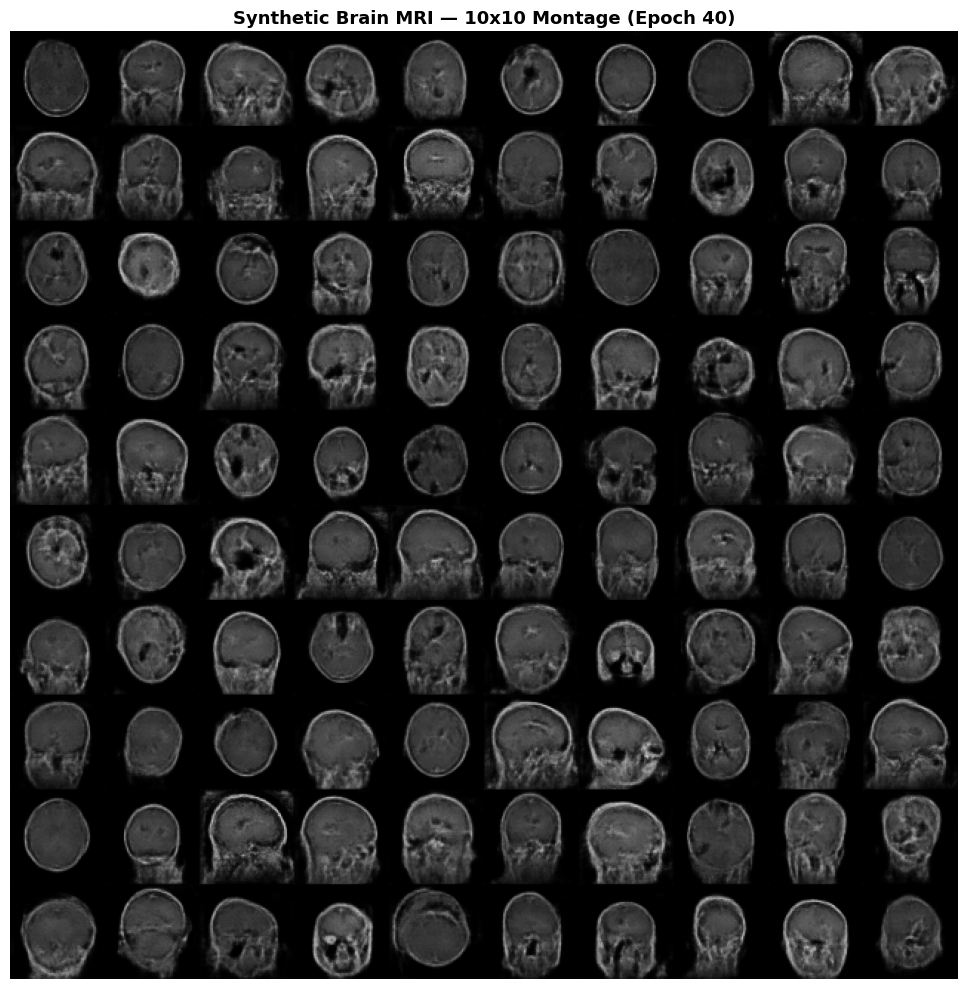

Epoch  40/50 | D=-4.2425 | G= 4.9432 | GP=0.4836 | 78.7s
Epoch  41/50 | D=-4.3191 | G= 4.7503 | GP=0.4841 | 78.1s
Epoch  42/50 | D=-4.2411 | G= 4.0180 | GP=0.4640 | 78.3s
Epoch  43/50 | D=-4.2636 | G= 5.1604 | GP=0.4708 | 78.0s
Epoch  44/50 | D=-4.3060 | G= 4.2165 | GP=0.5288 | 78.0s
Epoch  45/50 | D=-4.2995 | G= 5.1317 | GP=0.5028 | 78.1s
Epoch  46/50 | D=-4.3831 | G= 4.4282 | GP=0.5064 | 78.0s
Epoch  47/50 | D=-4.2958 | G= 4.9372 | GP=0.4660 | 78.0s
Epoch  48/50 | D=-4.4321 | G= 5.2789 | GP=0.5208 | 77.9s
Epoch  49/50 | D=-4.3337 | G= 5.2421 | GP=0.5404 | 78.0s


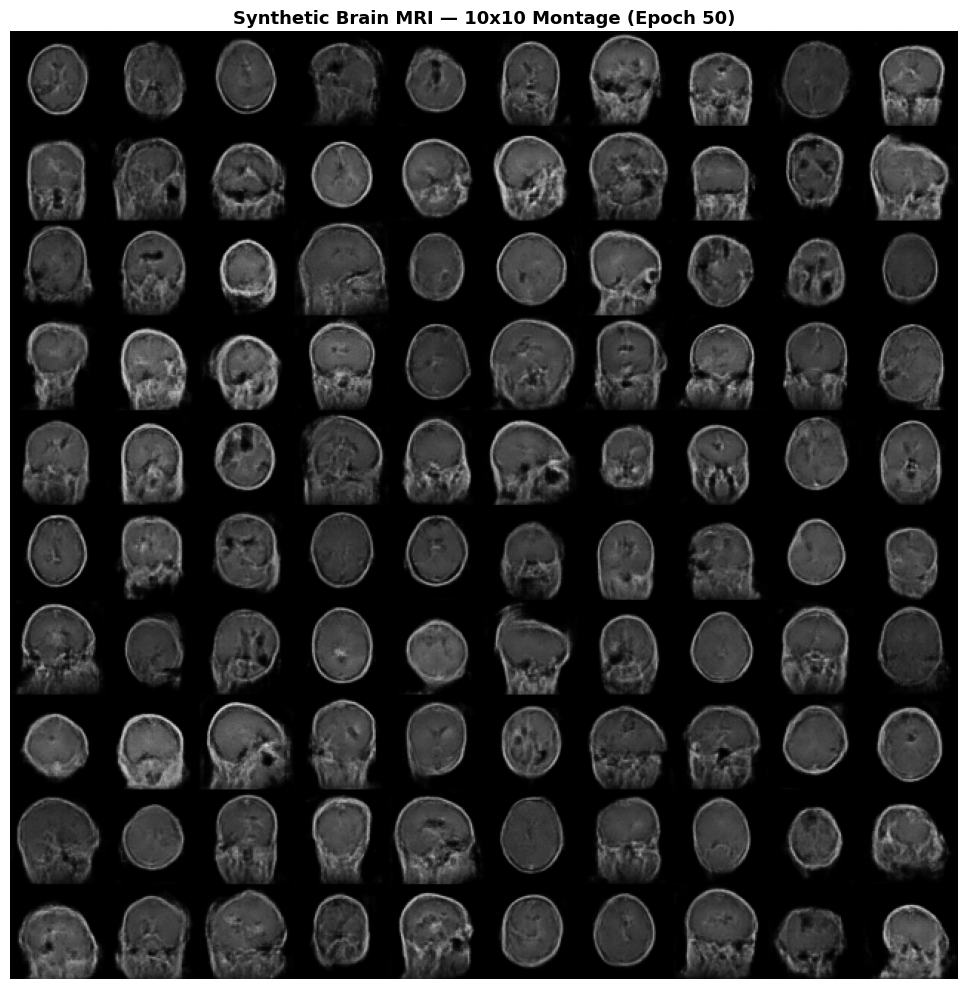

Epoch  50/50 | D=-4.3626 | G= 4.9765 | GP=0.4811 | 78.6s
------------------------------------------------------------
Training complete!


In [36]:
g_loss_hist, d_loss_hist, gp_hist = [], [], []
spe = len(real_images) // BATCH_SIZE
print(f"Training: class={TARGET_CLASS}  epochs={EPOCHS}  steps/epoch={spe}  n_critic={N_CRITIC}")
print("-"*60)

for epoch in range(1, EPOCHS+1):
    np.random.shuffle(real_images)
    ep_d, ep_g, ep_gp = [], [], []
    t0 = time.time()

    for step in range(spe):
        i0    = step * BATCH_SIZE
        batch = tf.constant(real_images[i0:i0+BATCH_SIZE])
        # Critic: N_CRITIC steps
        for _ in range(N_CRITIC):
            d_loss, gp_val = train_critic_step(batch)
        ep_d.append(float(d_loss)); ep_gp.append(float(gp_val))
        # Generator: 1 step
        g_loss = train_generator_step(BATCH_SIZE)
        ep_g.append(float(g_loss))

    avg_d, avg_g, avg_gp = np.mean(ep_d), np.mean(ep_g), np.mean(ep_gp)
    g_loss_hist.append(avg_g)
    d_loss_hist.append(avg_d)
    gp_hist.append(avg_gp)

    if epoch % 10 == 0 or epoch == 1 or epoch == EPOCHS:
        path = f"montages/montage_epoch_{epoch:03d}.png"
        show_montage(create_montage(generator, save_path=path), epoch=epoch)

    print(f"Epoch {epoch:3d}/{EPOCHS} | D={avg_d:7.4f} | G={avg_g:7.4f} | GP={avg_gp:6.4f} | {time.time()-t0:.1f}s")

print("-"*60)
print("Training complete!")

### 6.5 Save Weights

In [37]:
gp = os.path.join(WEIGHTS_DIR, f"gen_{TARGET_CLASS}.weights.h5")
cp = os.path.join(WEIGHTS_DIR, f"critic_{TARGET_CLASS}.weights.h5")
generator.save_weights(gp)
critic.save_weights(cp)
print(f"Generator weights : {gp}")
print(f"Critic weights    : {cp}")
print("Weights auto-loaded by app.py on the next request.")

Generator weights : saved_weights/gen_glioma.weights.h5
Critic weights    : saved_weights/critic_glioma.weights.h5
Weights auto-loaded by app.py on the next request.


## 7. Loss Curves

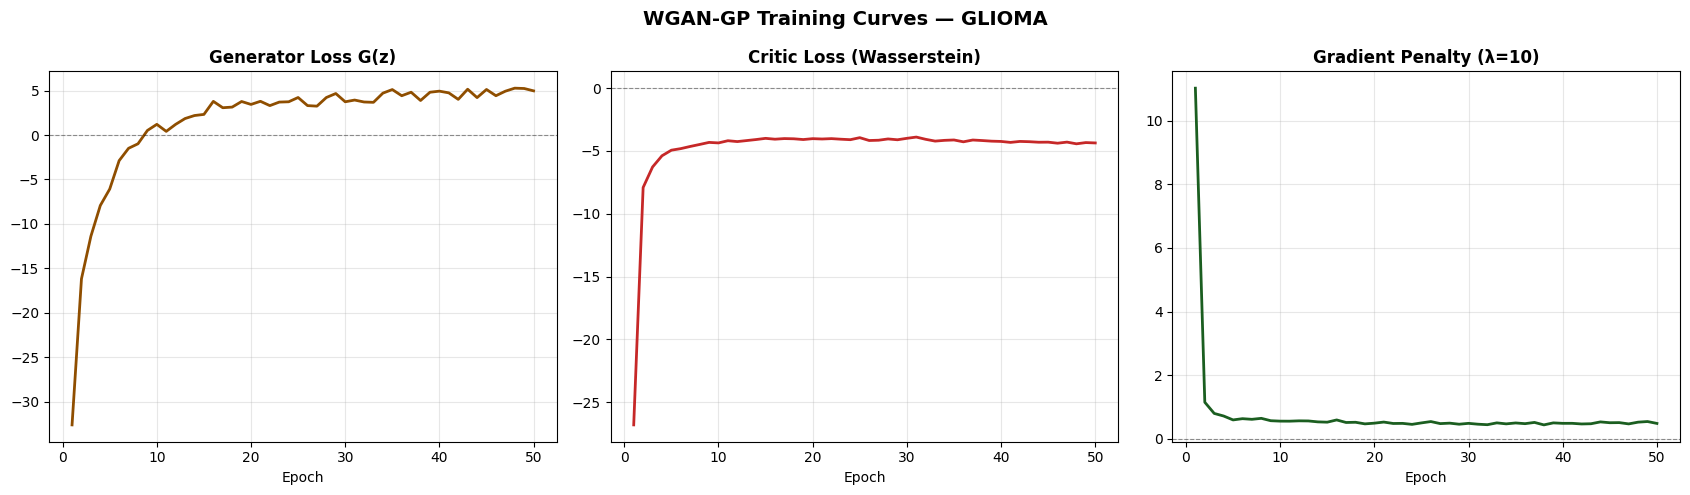

In [38]:
ep_range = range(1, len(g_loss_hist)+1)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
axes[0].plot(ep_range, g_loss_hist, color="#8F4E00", lw=2)
axes[0].set_title("Generator Loss G(z)",       fontweight="bold"); axes[0].grid(alpha=0.3)
axes[1].plot(ep_range, d_loss_hist, color="#C62828", lw=2)
axes[1].set_title("Critic Loss (Wasserstein)",  fontweight="bold"); axes[1].grid(alpha=0.3)
axes[2].plot(ep_range, gp_hist,    color="#1B5E20", lw=2)
axes[2].set_title(f"Gradient Penalty (λ={LAMBDA_GP})", fontweight="bold"); axes[2].grid(alpha=0.3)
for ax in axes: ax.set_xlabel("Epoch"); ax.axhline(0, color="black", ls="--", lw=0.8, alpha=0.4)
plt.suptitle(f"WGAN-GP Training Curves — {TARGET_CLASS.upper()}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("montages/loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Real vs Synthetic Comparison

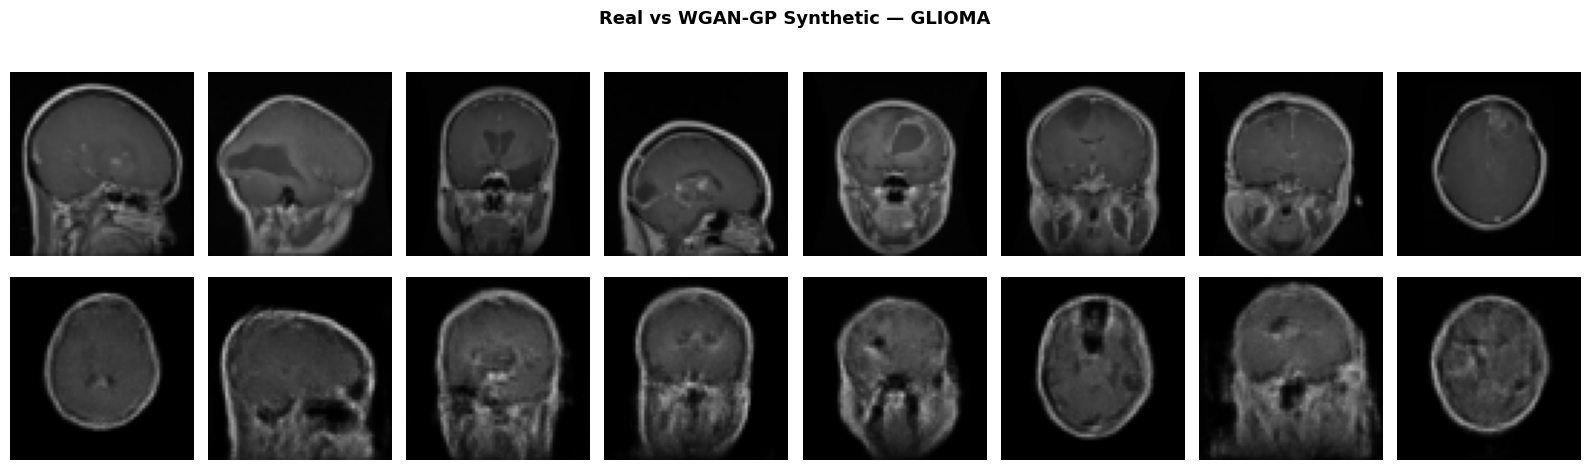

In [39]:
n_compare    = 8
real_samp    = real_images[np.random.choice(len(real_images), n_compare, replace=False)]
synth_samp   = generator(tf.random.normal([n_compare, NZ]), training=False).numpy()
real_disp    = np.clip((real_samp[:,:,:,0] + 1.0) / 2.0, 0.0, 1.0)
synth_disp   = np.clip((synth_samp[:,:,:,0] + 1.0) / 2.0, 0.0, 1.0)

fig, axes = plt.subplots(2, n_compare, figsize=(2*n_compare, 5))
for col in range(n_compare):
    axes[0,col].imshow(real_disp[col],  cmap="gray", vmin=0, vmax=1); axes[0,col].axis("off")
    axes[1,col].imshow(synth_disp[col], cmap="gray", vmin=0, vmax=1); axes[1,col].axis("off")
    if col==0:
        axes[0,col].set_ylabel("REAL",  fontsize=11, fontweight="bold", color="#1B5E20",
                                rotation=0, labelpad=42, va="center")
        axes[1,col].set_ylabel("SYNTH", fontsize=11, fontweight="bold", color="#8F4E00",
                                rotation=0, labelpad=42, va="center")
plt.suptitle(f"Real vs WGAN-GP Synthetic — {TARGET_CLASS.upper()}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("montages/real_vs_synthetic.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Evaluation Metrics
### 9.1 Quantitative Metrics

In [40]:
N_EVAL    = 500
real_eval = real_images[:N_EVAL, :, :, 0]
synth_eval= generator(tf.random.normal([N_EVAL, NZ]), training=False).numpy()[:,:,:,0]
r_flat    = real_eval.reshape(N_EVAL, -1)
s_flat    = synth_eval.reshape(N_EVAL, -1)

fidelity_mse = mean_squared_error(r_flat, s_flat)
cosine_sim   = float(np.diag(cosine_similarity(r_flat, s_flat)).mean())
r_hist, _    = np.histogram(r_flat.flatten(), bins=256, density=True)
s_hist, _    = np.histogram(s_flat.flatten(), bins=256, density=True)
kl_div       = float(kl_entropy(r_hist + 1e-10, s_hist + 1e-10))
diversity    = float(np.mean(np.var(s_flat, axis=0)))
cov          = float(np.mean((s_flat.max(0)-s_flat.min(0))/(r_flat.max(0)-r_flat.min(0)+1e-8)))*100
fid_approx   = (r_flat.mean()-s_flat.mean())**2 + (r_flat.std()-s_flat.std())**2

print("="*55)
print(f"  WGAN-GP Evaluation — {TARGET_CLASS.upper()}")
print("="*55)
for name, val in [("Fidelity MSE", f"{fidelity_mse:.6f}"),
                   ("Cosine Similarity", f"{cosine_sim:.4f}"),
                   ("KL Divergence", f"{kl_div:.4f}"),
                   ("Diversity (Var)", f"{diversity:.4f}"),
                   ("Coverage Ratio %", f"{cov:.2f}"),
                   ("FID approximation", f"{fid_approx:.6f}")]:
    print(f"  {name:<22}: {val}")

  WGAN-GP Evaluation — GLIOMA
  Fidelity MSE          : 0.083146
  Cosine Similarity     : 0.9361
  KL Divergence         : 0.3522
  Diversity (Var)       : 0.0433
  Coverage Ratio %      : 99.08
  FID approximation     : 0.000952


### 9.2 Pixel Distribution: Real vs Synthetic

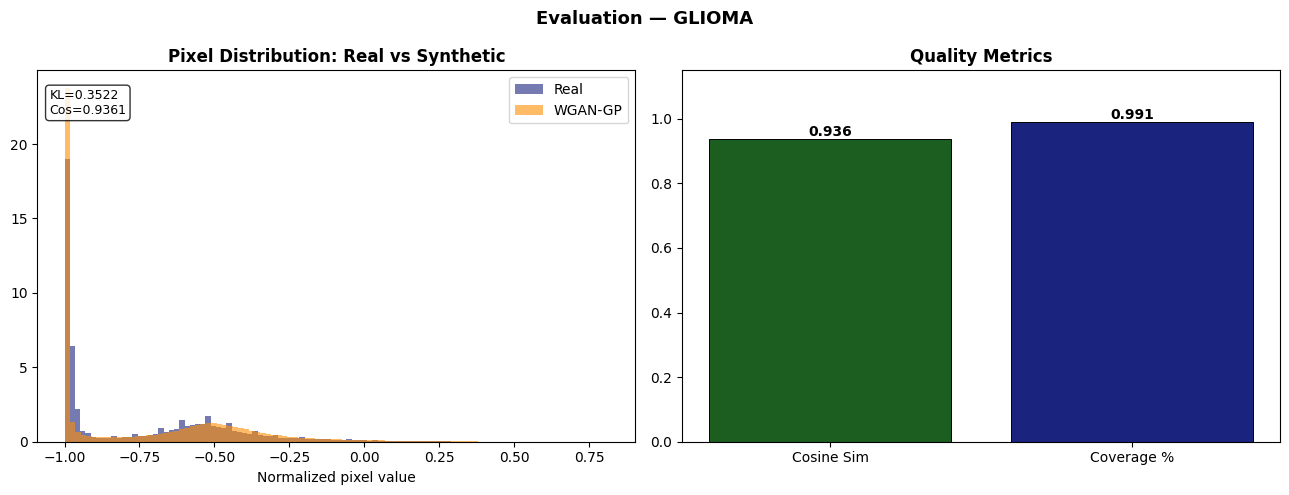

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(r_flat.flatten(), bins=100, density=True, alpha=0.6, color="#1A237E", label="Real")
axes[0].hist(s_flat.flatten(), bins=100, density=True, alpha=0.6, color="#FF8F00", label="WGAN-GP")
axes[0].set_title("Pixel Distribution: Real vs Synthetic", fontweight="bold")
axes[0].set_xlabel("Normalized pixel value")
axes[0].legend()
axes[0].text(0.02,0.95,f"KL={kl_div:.4f}\nCos={cosine_sim:.4f}",
             transform=axes[0].transAxes,va="top",fontsize=9,
             bbox=dict(boxstyle="round",fc="white",alpha=0.8))

metrics_bar = {"Cosine Sim": cosine_sim, "Coverage %": cov/100}
bars = axes[1].bar(metrics_bar.keys(), metrics_bar.values(),
                    color=["#1B5E20","#1A237E"], edgecolor="black", lw=0.7)
for b, v in zip(bars, metrics_bar.values()):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.3f}", ha="center", fontweight="bold")
axes[1].set_ylim(0,1.15)
axes[1].set_title("Quality Metrics", fontweight="bold")
plt.suptitle(f"Evaluation — {TARGET_CLASS.upper()}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("montages/evaluation_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Synthetic Image Generation
### 10.1 Final 10×10 Montage

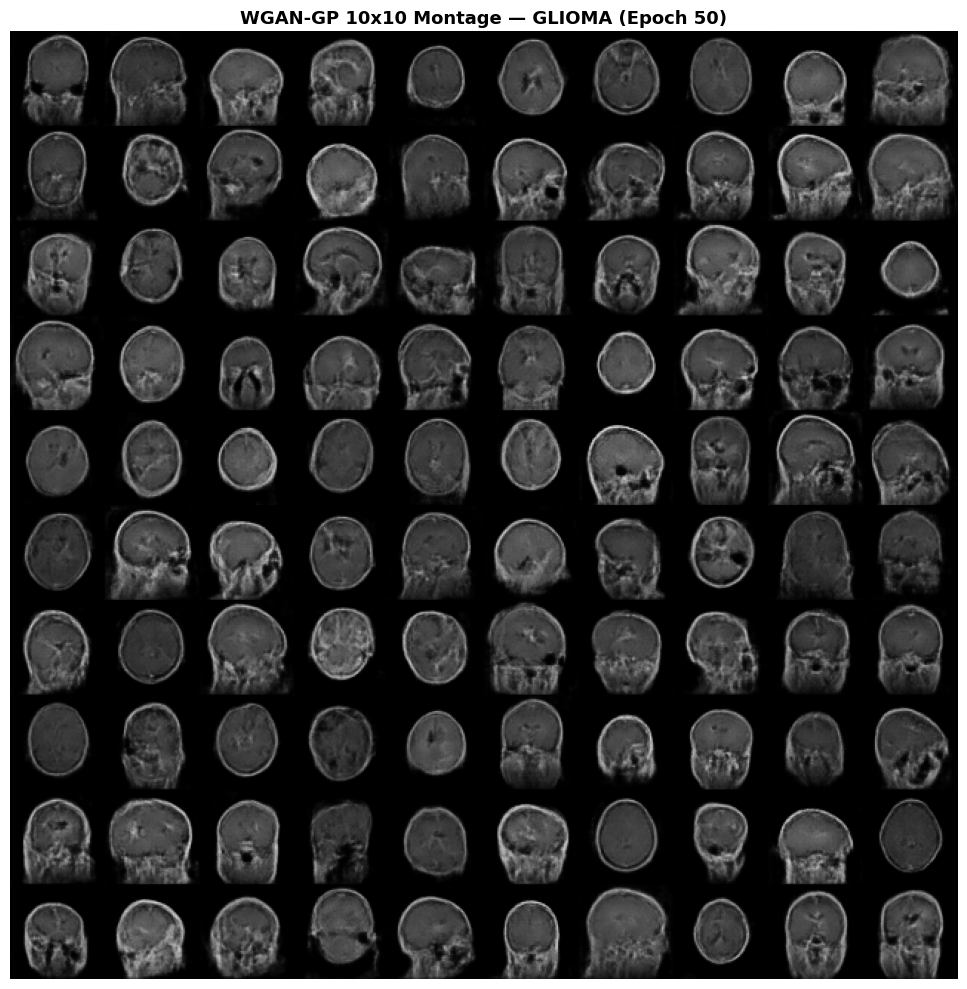

Saved: montages/final_glioma.png


In [42]:
final_canvas = create_montage(generator, save_path=f"montages/final_{TARGET_CLASS}.png")
show_montage(final_canvas, title=f"WGAN-GP 10x10 Montage — {TARGET_CLASS.upper()}", epoch=EPOCHS)
print(f"Saved: montages/final_{TARGET_CLASS}.png")

### 10.2 Export Synthetic Images to Disk

Exported 50 synthetic images → synthetic_glioma/


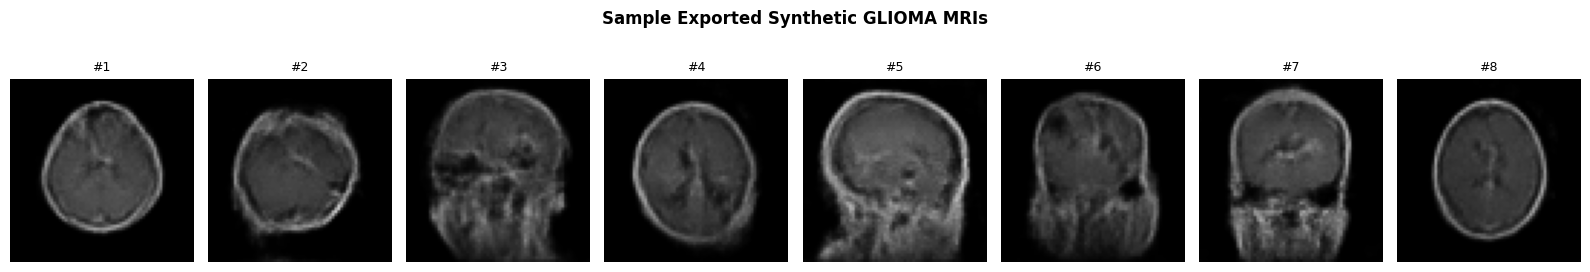

In [43]:
N_EXPORT  = 50
export_dir = f"synthetic_{TARGET_CLASS}"
os.makedirs(export_dir, exist_ok=True)
z_export   = tf.random.normal([N_EXPORT, NZ])
gen_imgs   = generator(z_export, training=False).numpy()
for i in range(N_EXPORT):
    # Map [-1, 1] -> [0, 255]
    arr = ((gen_imgs[i,:,:,0] + 1.0) * 127.5).clip(0,255).astype(np.uint8)
    Image.fromarray(arr,"L").save(os.path.join(export_dir,f"synth_{TARGET_CLASS}_{i+1:04d}.png"))
print(f"Exported {N_EXPORT} synthetic images → {export_dir}/")

fig, axes = plt.subplots(1, 8, figsize=(16, 3))
for i, ax in enumerate(axes):
    disp_img = np.clip((gen_imgs[i,:,:,0] + 1.0) / 2.0, 0.0, 1.0)
    ax.imshow(disp_img, cmap="gray", vmin=0, vmax=1); ax.axis("off"); ax.set_title(f"#{i+1}",fontsize=9)
plt.suptitle(f"Sample Exported Synthetic {TARGET_CLASS.upper()} MRIs", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

### 10.3 Latent Space Interpolation

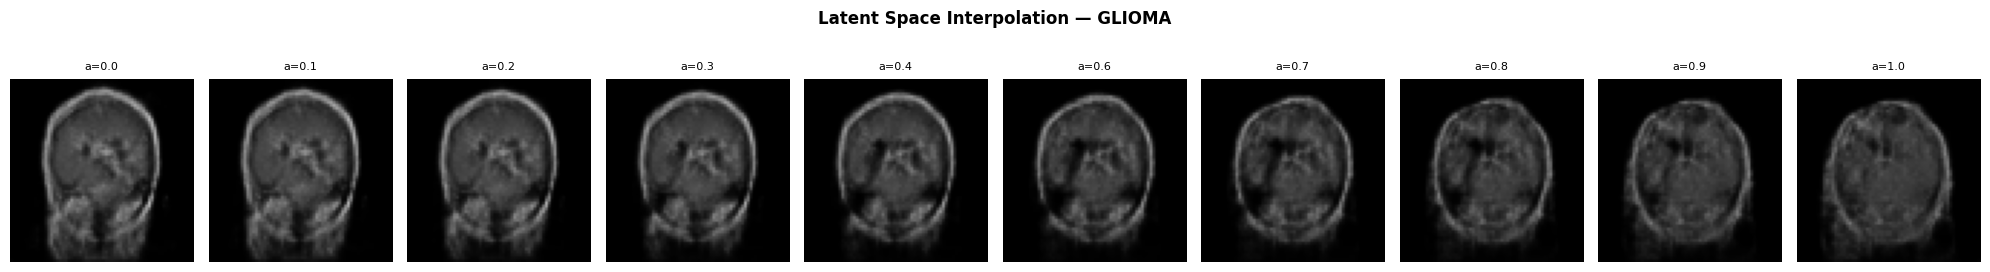

In [44]:
n_steps = 10
z_a = tf.random.normal([1, NZ]).numpy()
z_b = tf.random.normal([1, NZ]).numpy()
alphas  = np.linspace(0, 1, n_steps)
z_interp = np.array([(1-a)*z_a + a*z_b for a in alphas]).squeeze(1)
interp_imgs = generator(tf.constant(z_interp, dtype=tf.float32), training=False).numpy()[:,:,:,0]
interp_disp = np.clip((interp_imgs + 1.0) / 2.0, 0.0, 1.0)

fig, axes = plt.subplots(1, n_steps, figsize=(2*n_steps, 3))
for i, ax in enumerate(axes):
    ax.imshow(interp_disp[i], cmap="gray", vmin=0, vmax=1); ax.axis("off")
    ax.set_title(f"a={alphas[i]:.1f}", fontsize=8)
plt.suptitle(f"Latent Space Interpolation — {TARGET_CLASS.upper()}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("montages/latent_interpolation.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Load Pre-trained Weights & Inference (No Re-training)

Loaded: saved_weights/gen_glioma.weights.h5


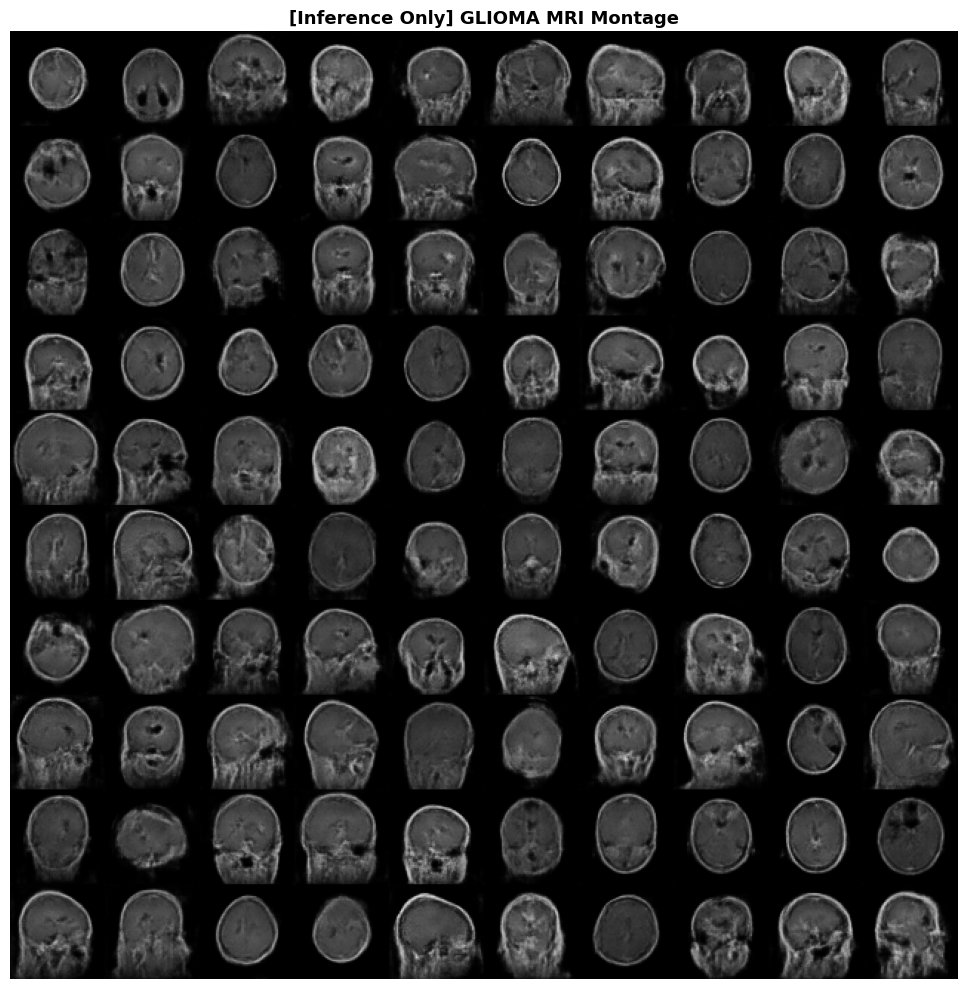

In [45]:
infer_class = TARGET_CLASS   # Change to any saved class
gen_path    = os.path.join(WEIGHTS_DIR, f"gen_{infer_class}.weights.h5")

if os.path.exists(gen_path):
    gen_inf = build_generator()
    _       = gen_inf(tf.zeros([1, NZ]), training=False)   # Build weights
    gen_inf.load_weights(gen_path)
    print(f"Loaded: {gen_path}")
    canvas = create_montage(gen_inf, save_path=f"montages/inference_{infer_class}.png")
    show_montage(canvas, title=f"[Inference Only] {infer_class.upper()} MRI Montage")
else:
    print(f"No weights at: {gen_path}  — run training first.")

## 12. Summary

| Component | Detail |
|-----------|--------|
| **Dataset** | 7,200 Brain MRI images (glioma · meningioma · pituitary · notumor) |
| **Preprocessing** | Grayscale resize 64×64, normalize [-1, 1] |
| **Generator** | z(200) → Dense(16384) → Reshape(4,4,1024) → 4×Conv2DTranspose → Tanh → 64×64×1 |
| **Critic** | 64×64×1 → 4×Conv2D(128·256·512·1024) [No BN — 1-Lipschitz] → Flatten → Dense(1) |
| **Loss** | Wasserstein + Gradient Penalty (λ=10) |
| **Optimizer** | Adam (lr=2e-4 · β₁=0.5 · β₂=0.9) |
| **Critic/Gen ratio** | 5 critic updates : 1 generator update |
| **Output** | 64×64 grayscale synthetic brain MRI · 10×10 montage |
| **Saved weights** | `saved_weights/gen_{class}.weights.h5` → auto-loaded by `app.py` |

> **App Integration**: Train this notebook → weights are saved → open the web app → select tumor class → click **Generate Synthetic MRI** — the app uses the trained generator automatically.
